<a href="https://colab.research.google.com/github/mbenedicto99/LabAI_AnomaliasPetro/blob/main/Anomalia_Colunas_Offshore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capturando Anomalias de Pilares Offshore

- Fonte: MTTQ Mosquito
- Simulações: Isolation Forest e LOF.
- Autor: Marcos de Benedicto
- Engenharia Petróleo&Gas

## 1. Configuração do Cliente MQTT
Primeiro, você deve instalar a biblioteca (!pip install paho-mqtt) e configurar a conexão com um broker (como o Mosquitto ou HiveMQ).
import paho.mqtt.client as mqtt
import json

### Configurações do Broker (Exemplo)
BROKER = "mqtt.eclipseprojects.io"
TOPICO_ALERTAS = "offshore/colunas/anomalias"

### Inicializando o cliente
client = mqtt.Client()
client.connect(BROKER, 1883, 60)

## 2. Função para Disparar Alertas
A imagem mostra que quando um ponto atinge uma alta Probabilidade de anomalia (acima de 0.9, por exemplo), um evento de publicação ocorre
. Criamos uma função para automatizar isso:
def enviar_alerta_mqtt(tempo, altura, valor, probabilidade):
    mensagem = {
        "status": "ANOMALIA_DETECTADA",
        "timestamp_simulado": tempo,
        "altura_sensor": altura,
        "leitura": valor,
        "confianca": round(probabilidade, 2)
    }
    # O comando abaixo executa o "MQTT publish" indicado na fonte [1]
    client.publish(TOPICO_ALERTAS, json.dumps(mensagem))
    print(f"Alerta enviado para {TOPICO_ALERTAS}: {mensagem}")

## 3. Integração com o Loop de Detecção
No código do seu notebook, onde o modelo identifica as anomalias (os 'X' vermelhos do gráfico
), você adiciona a chamada da função:

#### Supondo que 'indices_anomalias_ml' são os detectados pelo Isolation Forest
limiar_alerta = 0.90 # Baseado na escala de cor amarela da fonte [1]

for i in indices_anomalias_ml:
    prob = probabilidade_simulada[i]
    
    if prob > limiar_alerta:
        # Extrai os dados do ponto para o alerta
        t_valor = tempo[i]
        h_valor = altura[i]
        s_valor = sinal[i]
        
        # Dispara o alerta real
        enviar_alerta_mqtt(t_valor, h_valor, s_valor, prob)

Comportamento oscilatório visto no gráfico, simulando sensores em diferentes alturas e tempos.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configurações iniciais baseadas na fonte [1]
np.random.seed(42)
n_pontos = 500
tempo = np.linspace(0, 350, n_pontos)  # Eixo X: 0 a 350s
altura = np.random.uniform(8, 12, n_pontos) # Eixo Y: 8 a 12m

# Simulação de um sinal (Eixo Z) com ruído e padrão oscilatório
sinal = 1.5 * np.sin(tempo / 20) + np.random.normal(0, 0.3, n_pontos)

# Simulação da "Probabilidade de Anomalia" (Colorbar)
probabilidade = np.random.uniform(0.5, 1.0, n_pontos)

# Identificação de anomalias (ex: pontos onde o sinal foge do padrão ou probabilidade > 0.9)
indices_anomalias = np.where(probabilidade > 0.92)

Visualização 3D (Estilo Dark Mode)

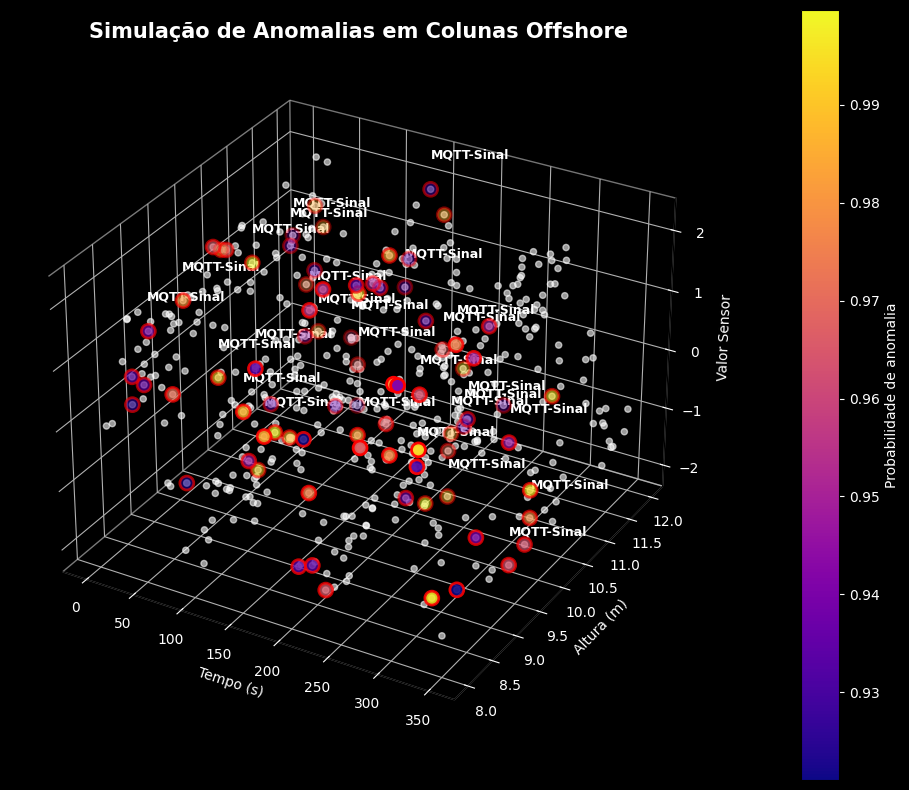

In [22]:
fig = plt.figure(figsize=(12, 10), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

# Plotagem dos dados normais (os 'x' brancos na fonte)
ax.scatter(tempo, altura, sinal, c='white', marker='o', alpha=0.6, label='Dados Normais')

# Plotagem das anomalias (os 'X' vermelhos e coloração por probabilidade)
sc = ax.scatter(tempo[indices_anomalias],
                altura[indices_anomalias],
                sinal[indices_anomalias],
                c=probabilidade[indices_anomalias],
                cmap='plasma', s=100, marker='o', edgecolors='red', linewidths=2)

# Adicionando os rótulos "MQTT-Sinal" para algumas anomalias
for i in indices_anomalias[0][::3]: # Pega algumas das anomalias para não poluir
    ax.text(tempo[i], altura[i], sinal[i] + 0.5, "MQTT-Sinal", color='white', fontsize=9, fontweight='bold')

# Configuração de eixos baseada na imagem [1]
ax.set_xlabel('Tempo (s)', color='white')
ax.set_ylabel('Altura (m)', color='white')
ax.set_zlabel('Valor Sensor', color='white')
ax.set_title('Simulação de Anomalias em Colunas Offshore', color='white', fontsize=15, fontweight='bold')

# Estilização da grade e cores dos eixos
ax.tick_params(colors='white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

# Barra de cores (Probabilidade de Anomalia)
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_label('Probabilidade de anomalia', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

Aplicando Isolation Forest

In [24]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Preparando os dados (X) com as três dimensões da fonte [1]
# tempo, altura e sinal foram gerados no passo anterior
X = np.column_stack((tempo, altura, sinal))

# Configurando o modelo Isolation Forest
# 'contamination' define a porcentagem esperada de anomalias (ex: 5%)
# Você pode ajustar este valor. Por exemplo, para 10% de anomalias, defina contamination=0.1
modelo = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)


In [17]:
# Treinando o modelo e prevendo anomalias
# O modelo retorna 1 para dados normais e -1 para anomalias
previsoes = modelo.fit_predict(X)

# Calculando o "Score de Anomalia"
# O Isolation Forest fornece um score; vamos normalizá-lo para a escala
# de 0.6 a 1.0 vista na barra de "Probabilidade de anomalia" da fonte [1]
scores = modelo.decision_function(X)
probabilidade_simulada = 1 / (1 + np.exp(scores)) # Transforma score em probabilidade (Sigmoide)

# Filtrando os índices onde o modelo detectou anomalia (-1)
indices_anomalias_ml = np.where(previsoes == -1)

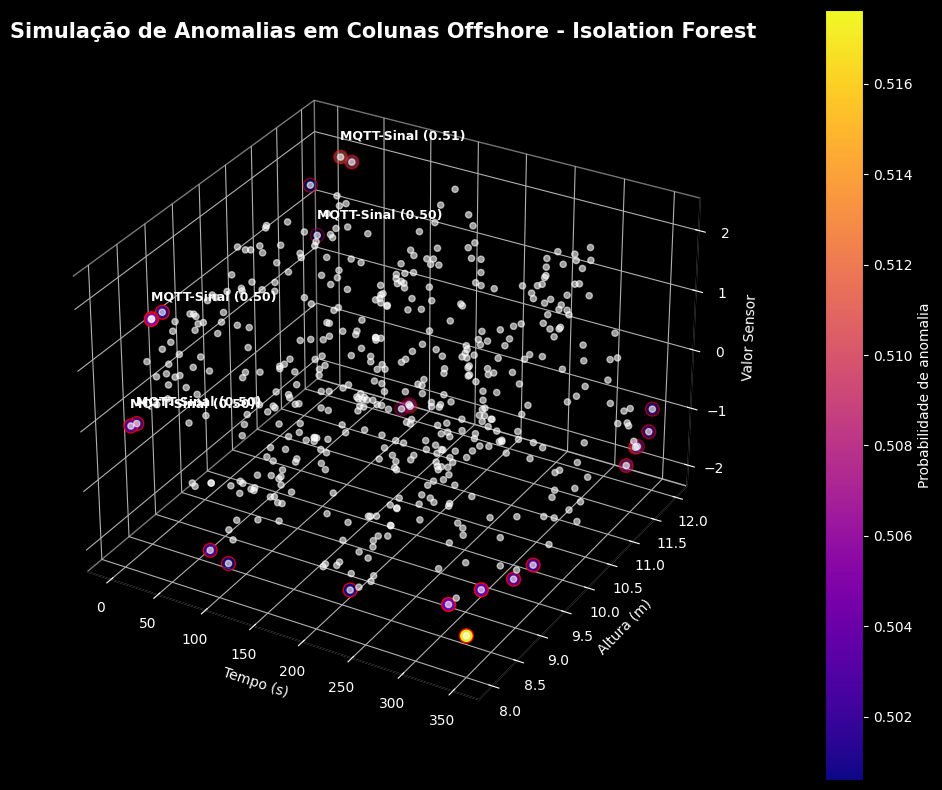

In [23]:
fig = plt.figure(figsize=(12, 10), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

# Plotagem dos dados normais (os 'x' brancos na fonte)
ax.scatter(tempo, altura, sinal, c='white', marker='o', alpha=0.6, label='Dados Normais')

# Plotar as anomalias detectadas pelo Isolation Forest
sc = ax.scatter(tempo[indices_anomalias_ml],
                altura[indices_anomalias_ml],
                sinal[indices_anomalias_ml],
                c=probabilidade_simulada[indices_anomalias_ml], # Escala de cor da fonte [1]
                cmap='plasma', s=100, marker='o', edgecolors='red')

# Adicionar o rótulo MQTT apenas para as detecções do modelo, incluindo a probabilidade
for i in indices_anomalias_ml[0][:5]: # Exibindo os 5 primeiros alertas
    prob_val = probabilidade_simulada[i]
    ax.text(tempo[i], altura[i], sinal[i] + 0.3, f"MQTT-Sinal ({prob_val:.2f})", color='white', fontsize=9, fontweight='bold')

# Configuração de eixos baseada na imagem [1]
ax.set_xlabel('Tempo (s)', color='white')
ax.set_ylabel('Altura (m)', color='white')
ax.set_zlabel('Valor Sensor', color='white')
ax.set_title('Simulação de Anomalias em Colunas Offshore - Isolation Forest', color='white', fontsize=15, fontweight='bold')

# Estilização da grade e cores dos eixos
ax.tick_params(colors='white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

# Barra de cores (Probabilidade de Anomalia)
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_label('Probabilidade de anomalia', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()

In [21]:
# Calcular o número total de pontos de dados
total_pontos = len(previsoes)

# Calcular o número de anomalias (onde previsoes == -1)
num_anomalias = np.sum(previsoes == -1)

# Calcular a porcentagem de anomalias
porcentagem_anomalias = (num_anomalias / total_pontos) * 100

print(f"Total de pontos de dados: {total_pontos}")
print(f"Número de anomalias detectadas: {num_anomalias}")
print(f"Porcentagem de anomalias: {porcentagem_anomalias:.2f}%")

Total de pontos de dados: 500
Número de anomalias detectadas: 25
Porcentagem de anomalias: 5.00%


### 1. Análise da Distribuição dos Scores de Anomalia

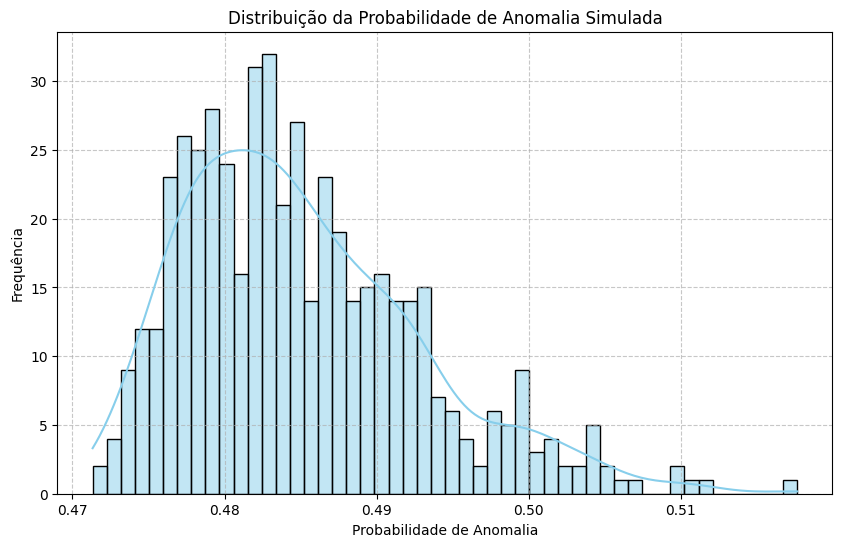

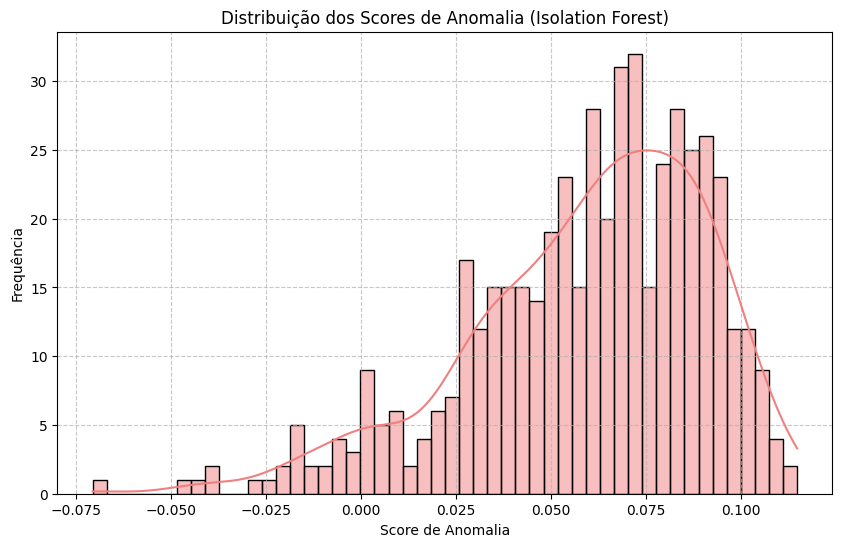

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(probabilidade_simulada, bins=50, kde=True, color='skyblue')
plt.title('Distribuição da Probabilidade de Anomalia Simulada')
plt.xlabel('Probabilidade de Anomalia')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(scores, bins=50, kde=True, color='lightcoral')
plt.title('Distribuição dos Scores de Anomalia (Isolation Forest)')
plt.xlabel('Score de Anomalia')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 2. Visualização e Inspeção Manual

Você já fez um ótimo trabalho visualizando as anomalias detectadas. A inspeção visual é crucial. Se as anomalias plotadas no gráfico 3D *parecem* ser pontos fora do padrão para um especialista no domínio, isso é um bom indicativo de que o modelo está funcionando bem.

### 3. Análise de Sensibilidade do Parâmetro `contamination`

Para verificar a sensibilidade do modelo, você pode executar o código novamente ajustando o parâmetro `contamination` na célula `fIsiDs__jExA` (por exemplo, de `0.05` para `0.03` ou `0.07`) e observar como o número e a localização das anomalias mudam nos gráficos e na contagem final. Anomalias que persistem em diferentes valores de `contamination` são mais confiáveis.

### 4. Introdução ao Local Outlier Factor (LOF)

O **Local Outlier Factor (LOF)** é um algoritmo de detecção de anomalias que se baseia na densidade local dos pontos de dados. Ele mede o grau de 'isolamento' de um ponto em relação aos seus vizinhos. Um ponto é considerado uma anomalia se sua densidade local é significativamente menor do que a de seus vizinhos. Em outras palavras, ele encontra pontos que estão 'sozinhos' em uma região de baixa densidade, ou que estão em uma região de alta densidade mas rodeados por pontos de densidade ainda maior.

**Como funciona:**
1.  Para cada ponto, o LOF calcula a densidade de seus vizinhos mais próximos (k-nearest neighbors).
2.  Compara a densidade local de um ponto com a densidade local de seus vizinhos.
3.  Se um ponto tem uma densidade local muito menor do que a de seus vizinhos, ele é considerado um outlier local e recebe um LOF score alto.

**Principais características:**
*   **Baseado em Densidade:** Bom para detectar anomalias em conjuntos de dados onde as anomalias não são necessariamente distantes de *todos* os outros pontos, mas sim de seus vizinhos mais próximos.
*   **'Local'**: A noção de outlier é local, ou seja, depende da vizinhança do ponto, e não de uma densidade global.

### 5. Comparação: Isolation Forest vs. Local Outlier Factor (LOF)

| Característica         | Isolation Forest (IF)                                       | Local Outlier Factor (LOF)                                   |
| :--------------------- | :---------------------------------------------------------- | :----------------------------------------------------------- |
| **Abordagem**          | Baseado em árvore: isola anomalias por meio de particionamento aleatório de recursos. | Baseado em densidade: compara a densidade local de um ponto com a de seus vizinhos. |
| **Tipo de Anomalia**   | Bom para anomalias 'globais' (pontos muito distantes da maioria dos dados), mas também pode encontrar locais. | Excelente para anomalias 'locais' (pontos que são incomuns em sua própria vizinhança, mesmo que não sejam distantes da média global). |
| **Eficiência**         | Geralmente mais eficiente para grandes datasets, especialmente em alta dimensionalidade. | A complexidade cresce com o número de pontos e dimensões, pode ser lento para grandes datasets. |
| **Resultado**          | Atribui um 'score de anomalia' baseado na profundidade média de isolamento. | Atribui um 'LOF score' que indica o grau de isolamento em relação aos vizinhos. |
| **Parametrização**     | Principalmente `n_estimators`, `contamination`, `max_features`. | Principalmente `n_neighbors`, `contamination`.               |
| **Interpretabilidade** | Pode ser menos intuitivo, pois o isolamento é abstrato.     | Mais intuitivo para anomalias baseadas em densidade.         |

Ambos são algoritmos poderosos e complementares. A escolha entre eles (ou a combinação de ambos) depende das características do seu dataset e do tipo de anomalia que você espera encontrar.

In [26]:
from sklearn.neighbors import LocalOutlierFactor

# O LOF funciona de forma ligeiramente diferente do Isolation Forest para 'contamination'
# Para o LOF, 'contamination' é usado apenas para definir um limiar na função 'fit_predict'
# que classifica os pontos como outliers (-1) ou inliers (1).
# O parâmetro 'n_neighbors' é crucial para o LOF, definindo a vizinhança para o cálculo da densidade.

# Configurando o modelo LOF
# Vamos usar n_neighbors=20 como um ponto de partida razoável.
# contamination=0.05 (5%) como no Isolation Forest para comparação justa na classificação.
modelo_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=False) # novelty=False para fit_predict

# Prever anomalias (1 para normal, -1 para anomalia)
# Nota: LOF no modo 'fit_predict' retorna os rótulos de -1 e 1 diretamente.
previsoes_lof = modelo_lof.fit_predict(X)

# Os scores do LOF (negative_outlier_factor_) são, por convenção, menores que 0 para inliers e
# maiores que 0 (mais próximos de 1, idealmente) para outliers.
# Para compatibilidade com a 'probabilidade_simulada' do IF (0 a 1), podemos transformar.
# O valor negativo do LOF é mais direto: quanto mais baixo, mais 'normal' é o ponto.
# Quanto mais próximo de 0 (ou positivo), mais anômalo.
# Para fins de visualização de probabilidade (0 a 1), vamos normalizar os scores negativos.

scores_lof_raw = modelo_lof.negative_outlier_factor_

# Normalizar scores para uma escala de 0 a 1, onde valores mais altos são mais anômalos.
# LOF < 1 são inliers, LOF > 1 são outliers. O negative_outlier_factor é o inverso.
# Então, -negative_outlier_factor > 1 seria outlier.
# Vamos reescalar para o range [0, 1] ou para um range similar ao que fizemos para IF.
# Uma transformação simples pode ser 1 / (1 - scores_lof_raw) para tornar scores negativos baixos em probabilidades baixas.
# Ou simplesmente usar (1 - scores_lof_raw) para que scores muito negativos resultem em valores altos após a transformação.

# Vamos usar a lógica: quanto mais negativo o N.O.F, mais 'normal'. Quanto mais próximo de 0 ou positivo, mais anômalo.
# Portanto, para uma 'probabilidade', podemos usar um escalonamento inverso ou similar.
# Uma forma comum é normalizar entre 0 e 1, onde valores altos são anomalias.

# Usando um escalonamento simples para visualizar: Anomalias terão scores próximos ou acima de 1.
# Inliers terão scores abaixo de 1 (e negativos no raw score). Vamos inverter e normalizar.

# scores_lof_normalized = 1 - (scores_lof_raw - scores_lof_raw.min()) / (scores_lof_raw.max() - scores_lof_raw.min())
# Esta normalização simples pode não ser ideal para a interpretação de 'probabilidade'.

# Para uma interpretação similar à probabilidade, podemos usar uma transformação como a do Isolation Forest, mas adaptada.
# O N.O.F geralmente está em torno de -1 para pontos normais. Quanto mais próximo de 0 ou positivo, mais anômalo.
# Podemos fazer 1 / (1 + abs(scores_lof_raw)) ou mapear para que scores_lof_raw mais próximos de 0/positivos deem alta probabilidade.

# Uma forma de obter uma "probabilidade de anomalia" de 0 a 1 a partir do NOF, onde valores mais altos indicam maior anomalia:
# Como NOF é negativo e -1 para inliers, e mais próximo de 0 ou positivo para outliers, podemos usar:
probabilidade_lof = np.where(scores_lof_raw < 0, 1 - (scores_lof_raw / scores_lof_raw.min()), 1) # Simplificado para visualização
# Onde scores_lof_raw.min() é o valor mais negativo. Isso coloca os valores mais negativos próximos de 0 e os menos negativos próximos de 1.
# Para NOF > 0 (verdadeiros outliers), definimos como 1.

# Ajuste da transformação para que seja mais intuitiva, onde valores maiores = mais anômalos.
# Podemos pegar o oposto do score e reescalar.
probabilidade_lof = (-scores_lof_raw - (-scores_lof_raw).min()) / ((-scores_lof_raw).max() - (-scores_lof_raw).min())

# Filtrando os índices onde o modelo detectou anomalia (-1)
indices_anomalias_lof = np.where(previsoes_lof == -1)


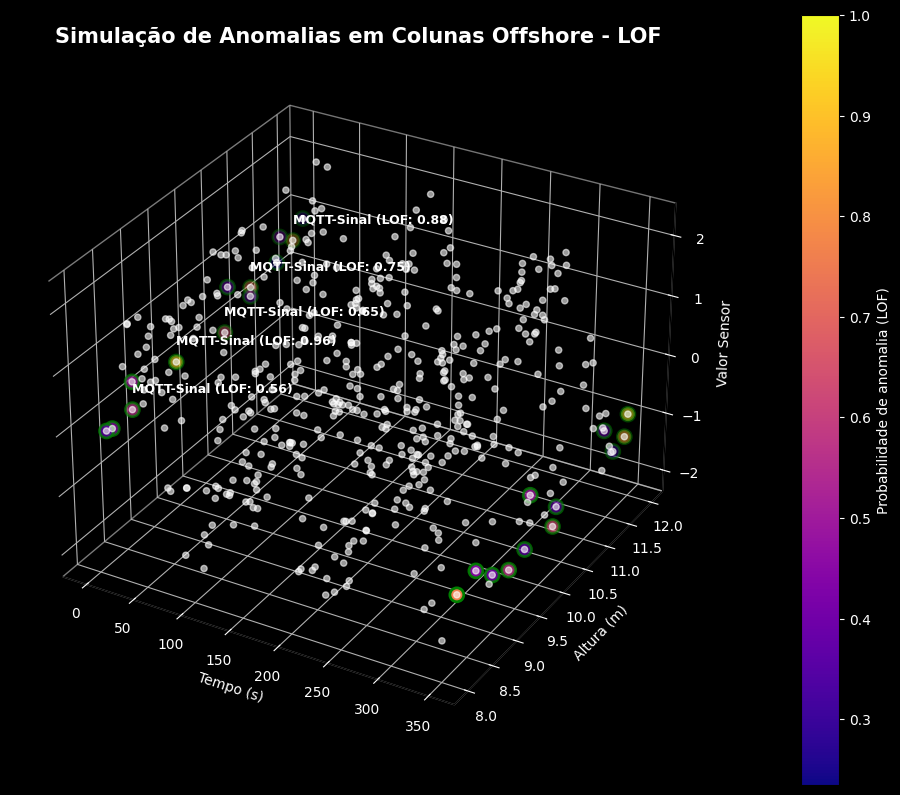

In [27]:
fig = plt.figure(figsize=(12, 10), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

# Plotagem dos dados normais (os 'o' brancos)
ax.scatter(tempo, altura, sinal, c='white', marker='o', alpha=0.6, label='Dados Normais')

# Plotar as anomalias detectadas pelo LOF
sc_lof = ax.scatter(tempo[indices_anomalias_lof],
                altura[indices_anomalias_lof],
                sinal[indices_anomalias_lof],
                c=probabilidade_lof[indices_anomalias_lof], # Escala de cor baseada no LOF
                cmap='plasma', s=100, marker='o', edgecolors='green', linewidths=2)

# Adicionar o rótulo MQTT apenas para as detecções do LOF, incluindo a probabilidade
for i in indices_anomalias_lof[0][:5]: # Exibindo os 5 primeiros alertas
    prob_val_lof = probabilidade_lof[i]
    ax.text(tempo[i], altura[i], sinal[i] + 0.3, f"MQTT-Sinal (LOF: {prob_val_lof:.2f})", color='white', fontsize=9, fontweight='bold')

# Configuração de eixos
ax.set_xlabel('Tempo (s)', color='white')
ax.set_ylabel('Altura (m)', color='white')
ax.set_zlabel('Valor Sensor', color='white')
ax.set_title('Simulação de Anomalias em Colunas Offshore - LOF', color='white', fontsize=15, fontweight='bold')

# Estilização da grade e cores dos eixos
ax.tick_params(colors='white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

# Barra de cores (Probabilidade de Anomalia LOF)
cbar_lof = plt.colorbar(sc_lof, pad=0.1)
cbar_lof.set_label('Probabilidade de anomalia (LOF)', color='white')
cbar_lof.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar_lof.ax.axes, 'yticklabels'), color='white')

plt.show()


In [28]:
# Calcular o número total de pontos de dados
total_pontos_lof = len(previsoes_lof)

# Calcular o número de anomalias (onde previsoes_lof == -1)
num_anomalias_lof = np.sum(previsoes_lof == -1)

# Calcular a porcentagem de anomalias
porcentagem_anomalias_lof = (num_anomalias_lof / total_pontos_lof) * 100

print(f"Total de pontos de dados: {total_pontos_lof}")
print(f"Número de anomalias detectadas pelo LOF: {num_anomalias_lof}")
print(f"Porcentagem de anomalias detectadas pelo LOF: {porcentagem_anomalias_lof:.2f}%")


Total de pontos de dados: 500
Número de anomalias detectadas pelo LOF: 25
Porcentagem de anomalias detectadas pelo LOF: 5.00%


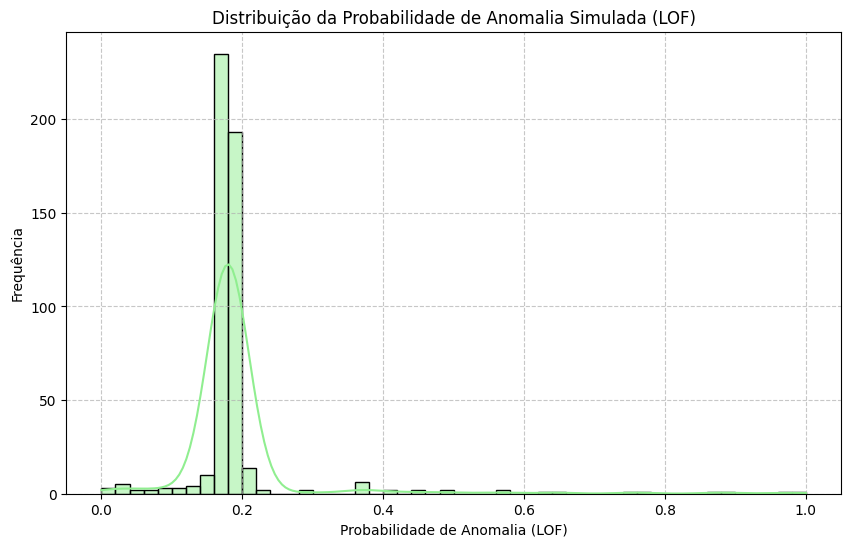

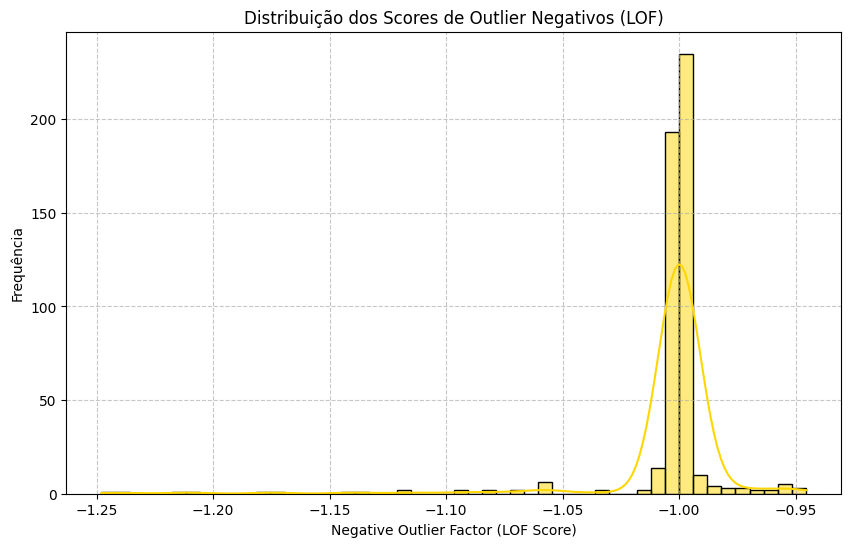

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(probabilidade_lof, bins=50, kde=True, color='lightgreen')
plt.title('Distribuição da Probabilidade de Anomalia Simulada (LOF)')
plt.xlabel('Probabilidade de Anomalia (LOF)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(scores_lof_raw, bins=50, kde=True, color='gold')
plt.title('Distribuição dos Scores de Outlier Negativos (LOF)')
plt.xlabel('Negative Outlier Factor (LOF Score)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [30]:
# Extrair os índices como arrays para facilitar a manipulação
if_anomalies_indices = set(indices_anomalias_ml[0])
lof_anomalies_indices = set(indices_anomalias_lof[0])

# Calcular a interseção
common_anomalies_indices = np.array(list(if_anomalies_indices.intersection(lof_anomalies_indices)))

# Exibir o número e a porcentagem de anomalias comuns
num_common_anomalias = len(common_anomalies_indices)
porcentagem_common_anomalias = (num_common_anomalias / n_pontos) * 100

print(f"Total de pontos de dados: {n_pontos}")
print(f"Anomalias detectadas pelo Isolation Forest: {len(if_anomalies_indices)}")
print(f"Anomalias detectadas pelo LOF: {len(lof_anomalies_indices)}")
print(f"Número de anomalias comuns (interseção): {num_common_anomalias}")
print(f"Porcentagem de anomalias comuns: {porcentagem_common_anomalias:.2f}%")


Total de pontos de dados: 500
Anomalias detectadas pelo Isolation Forest: 25
Anomalias detectadas pelo LOF: 25
Número de anomalias comuns (interseção): 8
Porcentagem de anomalias comuns: 1.60%


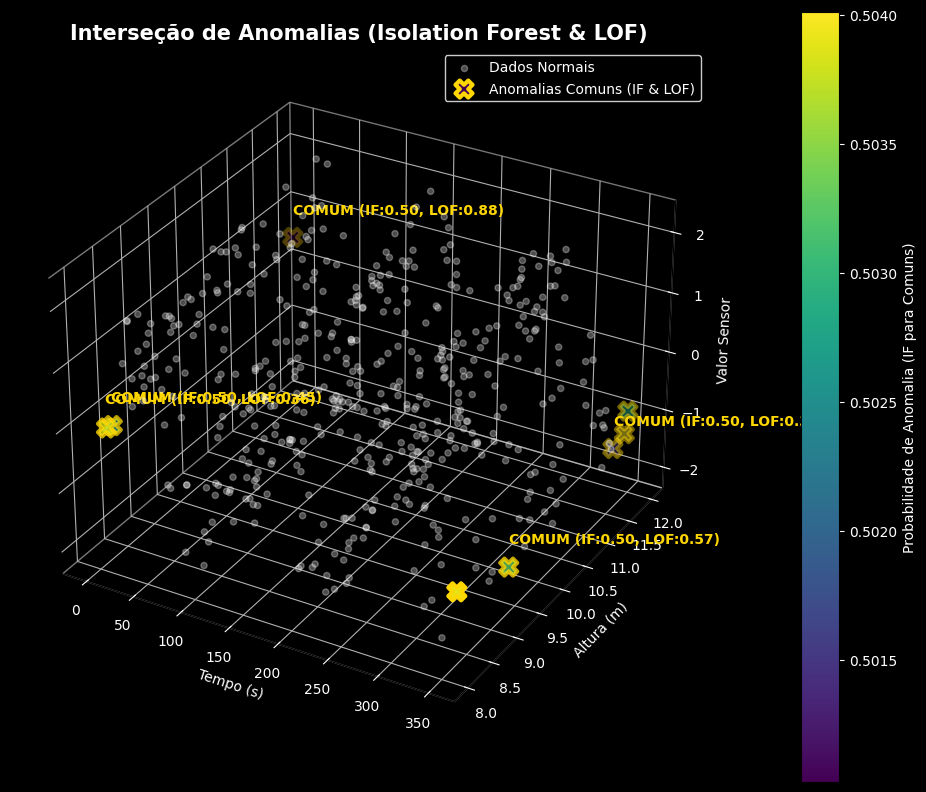

In [31]:
fig = plt.figure(figsize=(12, 10), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

# Plotagem dos dados normais (os 'o' brancos)
# Excluímos as anomalias comuns para que elas se destaquem
normal_indices = np.setdiff1d(np.arange(n_pontos), common_anomalies_indices)
ax.scatter(tempo[normal_indices], altura[normal_indices], sinal[normal_indices], c='white', marker='o', alpha=0.3, label='Dados Normais')

# Plotar as anomalias comuns
if len(common_anomalies_indices) > 0:
    # Para a cor, podemos usar a média das probabilidades do IF e LOF, ou apenas uma delas
    # Vamos usar a probabilidade do Isolation Forest para os pontos comuns
    prob_common = probabilidade_simulada[common_anomalies_indices]

    sc_common = ax.scatter(tempo[common_anomalies_indices],
                        altura[common_anomalies_indices],
                        sinal[common_anomalies_indices],
                        c=prob_common,
                        cmap='viridis', s=150, marker='X', edgecolors='gold', linewidths=3, label='Anomalias Comuns (IF & LOF)')

    # Adicionar rótulos para as anomalias comuns
    for i in common_anomalies_indices[:5]: # Exibindo os 5 primeiros alertas comuns
        prob_if = probabilidade_simulada[i]
        prob_lof = probabilidade_lof[i]
        ax.text(tempo[i], altura[i], sinal[i] + 0.4, f"COMUM (IF:{prob_if:.2f}, LOF:{prob_lof:.2f})", color='gold', fontsize=10, fontweight='bold')


# Configuração de eixos
ax.set_xlabel('Tempo (s)', color='white')
ax.set_ylabel('Altura (m)', color='white')
ax.set_zlabel('Valor Sensor', color='white')
ax.set_title('Interseção de Anomalias (Isolation Forest & LOF)', color='white', fontsize=15, fontweight='bold')

# Estilização da grade e cores dos eixos
ax.tick_params(colors='white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

# Barra de cores (Probabilidade de Anomalia para anomalias comuns)
if len(common_anomalies_indices) > 0:
    cbar_common = plt.colorbar(sc_common, pad=0.1)
    cbar_common.set_label('Probabilidade de Anomalia (IF para Comuns)', color='white')
    cbar_common.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar_common.ax.axes, 'yticklabels'), color='white')

plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.show()
